# Depth Agreement Evaluation
This notebook compares the absolute depth values obtained from the RealSense camera against the relative depth maps produced by the `Depth Anything V2` model.

**Kaggle secrets** (Settings → Secrets) — only needed on Kaggle:
| Secret name | Value |
|---|---|
| `github_token` | Personal access token with `repo` scope |

## 1 · Secrets & Repo Setup

In [1]:
import os
import sys
import subprocess

# ── Kaggle secrets (no-op when run locally) ───────────────────────────────────
TOKEN = None
try:
    from kaggle_secrets import UserSecretsClient
    _secrets  = UserSecretsClient()
    TOKEN     = _secrets.get_secret("github_token")
except Exception:
    pass

# ── Repo clone / pull (Kaggle only) ──────────────────────────────────────────
if TOKEN:
    REPO_URL = f"https://{TOKEN}@github.com/PaulOkwija/depth-aware-anon.git"
    REPO_DIR = "/kaggle/working/depth-aware-anon"
    if not os.path.exists(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)

Cloning into '/kaggle/working/depth-aware-anon'...


In [2]:
# Only run %cd on Kaggle; locally the CWD is already the repo root.
if TOKEN:
    %cd depth-aware-anon

/kaggle/working/depth-aware-anon


In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    # Fallback to parent dir if run from inside notebooks/
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / 'src').exists():
    raise FileNotFoundError('Run this notebook from the repository root or change PROJECT_ROOT manually.')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
PROJECT_ROOT

PosixPath('/kaggle/working/depth-aware-anon')

In [4]:
%pip install -q -r requirements.txt
%pip install -q scipy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 69.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 2 · Load Models

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import torch
from tqdm.auto import tqdm

from depth_anon.depth import load_depth_processor, load_depth_model, estimate_depth_map

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

# Configuration
# NOTE: If you are running on Kaggle, upload the eval_videos folder as a dataset
# and update this path to the correct Kaggle input path:
eval_folder = Path('/kaggle/input/datasets/paulmugume/validation/box_limit_video/box_limit_video')
if not eval_folder.exists():
    # Fallback to local if not on Kaggle
    eval_folder = PROJECT_ROOT / 'eval_videos' / 'box_limit_video'

rgb_dir = eval_folder / 'rgb_images'
depth_dir = eval_folder / 'depth_data'

# Load Depth Anything
model_id = 'depth-anything/Depth-Anything-V2-Small-hf'
print("Loading model...")
processor = load_depth_processor(model_id)
model = load_depth_model(model_id)
print('Model loaded successfully.')

Using device: cuda
Loading model...


preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

Model loaded successfully.


In [6]:
def compute_agreement(rs_depth, da_depth):
    # RealSense depth is 0 where invalid. Mask those out.
    valid_mask = rs_depth > 0
    if not valid_mask.any():
        return 0.0, 0.0
        
    rs_valid = rs_depth[valid_mask].astype(np.float32)
    da_valid = da_depth[valid_mask].astype(np.float32)
    
    # In depth.py, estimate_depth_map returns 1.0 for close and 0.0 for far.
    # RealSense returns raw mm, so small values = close, large = far.
    # We expect a NEGATIVE correlation. To make it positive, we flip DA back:
    da_valid_flipped = 1.0 - da_valid
    
    # Pearson: linear correlation
    pearson_corr, _ = scipy.stats.pearsonr(rs_valid, da_valid_flipped)
    
    # Spearman: monotonic rank correlation (often better for relative depth)
    spearman_corr, _ = scipy.stats.spearmanr(rs_valid, da_valid_flipped)
    
    return pearson_corr, spearman_corr

## 3 · Process Frames

In [7]:
# Get all frames
frame_paths = sorted(list(rgb_dir.glob('*.jpg')) + list(rgb_dir.glob('*.png')))
print(f'Found {len(frame_paths)} frames.')

pearson_scores = []
spearman_scores = []

# To process all frames, leave this as len(frame_paths)
frames_to_process = len(frame_paths) 

for i in tqdm(range(frames_to_process)):
    img_path = frame_paths[i]
    
    frame_stem = img_path.stem
    if frame_stem.startswith("frame_"):
        number = frame_stem.split("_")[1]
        depth_name = f"depth_{number}.npy"
    else:
        depth_name = frame_stem + ".npy"
        
    depth_path = depth_dir / depth_name
    
    if not depth_path.exists():
        continue
        
    frame_bgr = cv2.imread(str(img_path))
    rs_depth = np.load(depth_path)
    
    # Get depth map from model
    da_depth = estimate_depth_map(frame_bgr, processor, model, DEVICE)
    
    # Compute correlation
    p_corr, s_corr = compute_agreement(rs_depth, da_depth)
    
    # Handle NaN in case of flat depth maps
    if np.isnan(p_corr): p_corr = 0.0
    if np.isnan(s_corr): s_corr = 0.0
        
    pearson_scores.append(p_corr)
    spearman_scores.append(s_corr)

if pearson_scores:
    print(f'Average Pearson Correlation: {np.mean(pearson_scores):.4f}')
    print(f'Average Spearman Rank Correlation: {np.mean(spearman_scores):.4f}')
else:
    print("No matching depth maps found. Please check your eval_videos path.")

Found 846 frames.


  0%|          | 0/846 [00:00<?, ?it/s]

Average Pearson Correlation: -0.7222
Average Spearman Rank Correlation: -0.8961


## 4 · Visualization

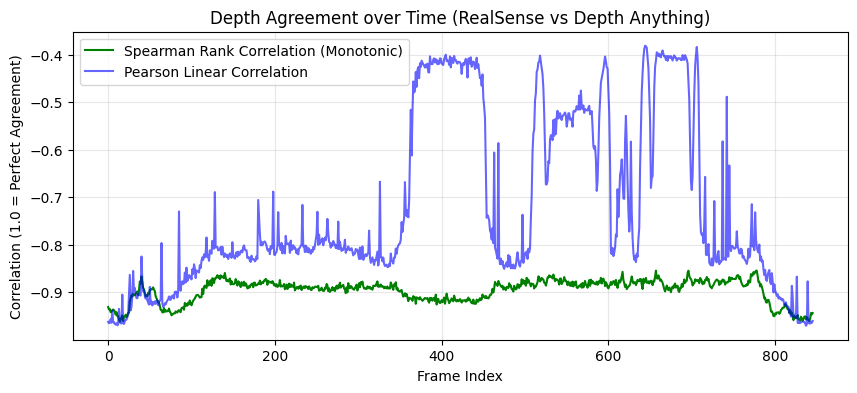

In [11]:
# Plot the correlation distribution
if spearman_scores:
    plt.figure(figsize=(10, 4))
    plt.plot(spearman_scores, label='Spearman Rank Correlation (Monotonic)', color='green')
    plt.plot(pearson_scores, label='Pearson Linear Correlation', color='blue', alpha=0.6)
    plt.title('Depth Agreement over Time (RealSense vs Depth Anything)')
    plt.xlabel('Frame Index')
    plt.ylabel('Correlation (1.0 = Perfect Agreement)')
    # plt.ylim(0, 1.0)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

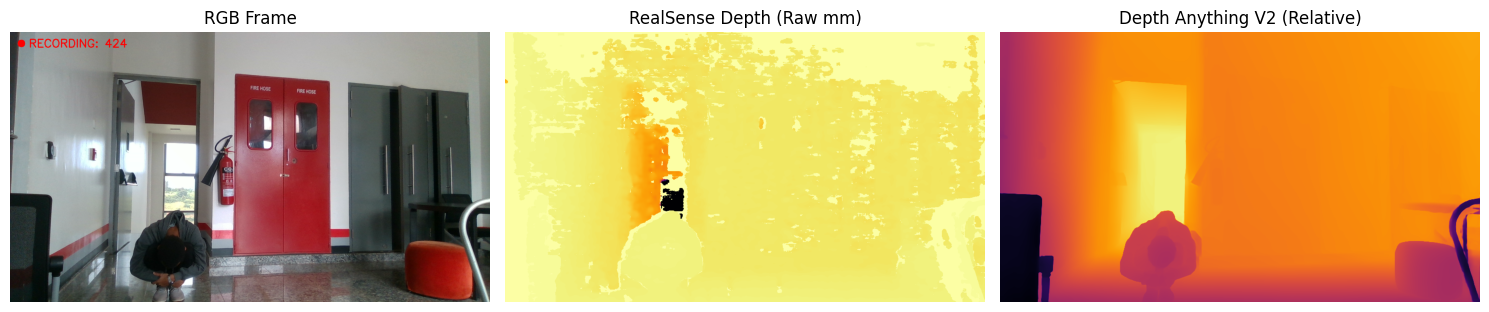

In [9]:
# Visualize a single frame side-by-side
if frame_paths:
    idx = len(frame_paths) // 2
    img_path = frame_paths[idx]

    frame_stem = img_path.stem
    if frame_stem.startswith("frame_"):
        number = frame_stem.split("_")[1]
        depth_name = f"depth_{number}.npy"
    else:
        depth_name = frame_stem + ".npy"
        
    depth_path = depth_dir / depth_name

    if depth_path.exists():
        frame_bgr = cv2.imread(str(img_path))
        rs_depth = np.load(depth_path)
        da_depth = estimate_depth_map(frame_bgr, processor, model, DEVICE)

        plt.figure(figsize=(15, 5))

        # RGB
        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
        plt.title('RGB Frame')
        plt.axis('off')

        # RealSense Depth
        plt.subplot(1, 3, 2)
        plt.imshow(rs_depth, cmap='inferno_r')
        plt.title('RealSense Depth (Raw mm)')
        plt.axis('off')

        # Depth Anything
        plt.subplot(1, 3, 3)
        plt.imshow(da_depth, cmap='inferno')
        plt.title('Depth Anything V2 (Relative)')
        plt.axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Depth file not found for visualization: {depth_path}")